# ENM404 Production Scheduling Project

## Job Shop Scheduling using Tabu Search

### Group 13

## FT10 Benchmark Instance Definition

In [6]:
import random
import time
import numpy as np
import pandas as pd

In [7]:
# FT10 / MT10 - Fisher and Thompson 10x10 Job-Shop instance

ft10_data = [
    [(0, 29), (1, 78), (2, 9),  (3, 36), (4, 49), (5, 11), (6, 62), (7, 56), (8, 44), (9, 21)],
    [(0, 43), (2, 90), (4, 75), (9, 11), (3, 69), (1, 28), (6, 46), (5, 46), (7, 72), (8, 30)],
    [(1, 91), (0, 85), (3, 39), (2, 74), (8, 90), (5, 10), (7, 12), (6, 89), (9, 45), (4, 33)],
    [(1, 81), (2, 95), (0, 71), (4, 99), (6, 9),  (8, 52), (7, 85), (3, 98), (9, 22), (5, 43)],
    [(2, 14), (0, 6),  (1, 22), (5, 61), (3, 26), (4, 69), (8, 21), (7, 49), (9, 72), (6, 53)],
    [(2, 84), (1, 2),  (5, 52), (3, 95), (8, 48), (9, 72), (0, 47), (6, 65), (4, 6),  (7, 25)],
    [(1, 46), (0, 37), (3, 61), (2, 13), (6, 32), (5, 21), (9, 32), (8, 89), (7, 30), (4, 55)],
    [(2, 31), (0, 86), (1, 46), (5, 74), (4, 32), (6, 88), (8, 19), (9, 48), (7, 36), (3, 79)],
    [(0, 76), (1, 69), (3, 76), (5, 51), (2, 85), (9, 11), (6, 40), (7, 89), (4, 26), (8, 74)],
    [(1, 85), (0, 13), (2, 61), (6, 7),  (8, 64), (9, 76), (5, 47), (3, 52), (4, 90), (7, 45)]
]

ft10_jobs = len(ft10_data)
ft10_machines = 10

print("FT10 jobs:", ft10_jobs)
print("FT10 machines:", ft10_machines)
print("Operations per job:", len(ft10_data[0]))

FT10 jobs: 10
FT10 machines: 10
Operations per job: 10


In [8]:
def generate_initial_solution(data):

    solution = []

    for job_id, job in enumerate(data):

        for operation_id in range(len(job)):

            solution.append((job_id, operation_id))

    random.shuffle(solution)

    return solution

In [9]:
def calculate_makespan(solution, data):

    machine_available = [0] * ft10_machines
    job_available = [0] * ft10_jobs

    schedule = []

    for job_id, operation_id in solution:

        machine_id, processing_time = data[job_id][operation_id]

        start_time = max(
            machine_available[machine_id],
            job_available[job_id]
        )

        end_time = start_time + processing_time

        machine_available[machine_id] = end_time
        job_available[job_id] = end_time

        schedule.append(
            (job_id, operation_id, machine_id, start_time, end_time)
        )

    makespan = max(job_available)

    return makespan, schedule

In [10]:
def generate_neighbor(solution):

    neighbor = solution.copy()

    i, j = random.sample(range(len(solution)), 2)

    neighbor[i], neighbor[j] = neighbor[j], neighbor[i]

    return neighbor

In [12]:
def tabu_search(
    data,
    machines,
    max_iterations=1000,
    tabu_tenure=7,
    neighborhood_size=50
):

    current_solution = generate_initial_solution(data)

    current_makespan, current_schedule = calculate_makespan(
        current_solution,
        data
    )

    best_solution = current_solution.copy()
    best_makespan = current_makespan
    best_schedule = current_schedule

    tabu_list = []

    convergence = []

    for iteration in range(max_iterations):

        neighborhood = []

        for _ in range(neighborhood_size):

            neighbor = generate_neighbor(current_solution)

            neighbor_makespan, neighbor_schedule = calculate_makespan(
                neighbor,
                data
            )

            neighborhood.append(
                (neighbor, neighbor_makespan, neighbor_schedule)
            )

        neighborhood.sort(key=lambda x: x[1])

        best_neighbor = None

        for neighbor, neighbor_makespan, neighbor_schedule in neighborhood:

            if neighbor not in tabu_list:

                best_neighbor = (
                    neighbor,
                    neighbor_makespan,
                    neighbor_schedule
                )

                break

        if best_neighbor is None:
            continue

        current_solution = best_neighbor[0]
        current_makespan = best_neighbor[1]
        current_schedule = best_neighbor[2]

        tabu_list.append(current_solution)

        if len(tabu_list) > tabu_tenure:
            tabu_list.pop(0)

        if current_makespan < best_makespan:

            best_solution = current_solution.copy()
            best_makespan = current_makespan
            best_schedule = current_schedule

        convergence.append(best_makespan)

    return (
        best_solution,
        best_schedule,
        best_makespan,
        convergence
    )

In [13]:
best_solution_ft10, best_schedule_ft10, best_makespan_ft10, convergence_ft10 = tabu_search(
    ft10_data,
    ft10_machines,
    max_iterations=1000,
    tabu_tenure=7,
    neighborhood_size=50
)

print("FT10 Best Makespan:", best_makespan_ft10)

FT10 Best Makespan: 655


In [14]:
def run_experiments(instance_data, num_machines, num_runs=10, max_iterations=1000, tabu_tenure=7, neighborhood_size=50):
    """
    Runs Tabu Search multiple times for a given benchmark instance.
    Returns statistical results and the best schedule.
    """

    results = []
    times = []

    overall_best_solution = None
    overall_best_schedule = None
    overall_best_makespan = float("inf")
    overall_best_convergence = None

    for run in range(num_runs):
        start_time = time.time()

        best_solution, best_schedule, best_makespan, convergence = tabu_search(
            instance_data,
            num_machines,
            max_iterations=max_iterations,
            tabu_tenure=tabu_tenure,
            neighborhood_size=neighborhood_size
        )

        end_time = time.time()
        runtime = end_time - start_time

        results.append(best_makespan)
        times.append(runtime)

        if best_makespan < overall_best_makespan:
            overall_best_solution = best_solution
            overall_best_schedule = best_schedule
            overall_best_makespan = best_makespan
            overall_best_convergence = convergence

        print(f"Run {run + 1}: Makespan = {best_makespan}, Time = {runtime:.2f} seconds")

    summary = {
        "Best": min(results),
        "Worst": max(results),
        "Mean": np.mean(results),
        "Std Dev": np.std(results),
        "Avg Time": np.mean(times)
    }

    return summary, results, times, overall_best_solution, overall_best_schedule, overall_best_convergence

In [15]:
ft10_summary, ft10_results, ft10_times, ft10_best_solution, ft10_best_schedule, ft10_best_convergence = run_experiments(
    ft10_data,
    ft10_machines,
    num_runs=10,
    max_iterations=1000,
    tabu_tenure=7,
    neighborhood_size=50
)

print("\nFT10 Summary:")
print(ft10_summary)

Run 1: Makespan = 655, Time = 3.54 seconds
Run 2: Makespan = 656, Time = 2.20 seconds
Run 3: Makespan = 656, Time = 2.14 seconds
Run 4: Makespan = 665, Time = 2.29 seconds
Run 5: Makespan = 655, Time = 2.21 seconds
Run 6: Makespan = 673, Time = 3.47 seconds
Run 7: Makespan = 656, Time = 2.24 seconds
Run 8: Makespan = 655, Time = 2.30 seconds
Run 9: Makespan = 667, Time = 2.20 seconds
Run 10: Makespan = 655, Time = 2.13 seconds

FT10 Summary:
{'Best': 655, 'Worst': 673, 'Mean': np.float64(659.3), 'Std Dev': np.float64(6.2136945531623935), 'Avg Time': np.float64(2.472656559944153)}


## FT10 Experimental Results and Visualization

In [16]:
ft10_best_known = 930
ft10_gap = ((ft10_summary["Best"] - ft10_best_known) / ft10_best_known) * 100

ft10_table = pd.DataFrame([{
    "Instance": "FT10",
    "Size": "10 x 10",
    "Best Known": ft10_best_known,
    "Best Found": ft10_summary["Best"],
    "Mean": round(ft10_summary["Mean"], 2),
    "Std Dev": round(ft10_summary["Std Dev"], 2),
    "Worst": ft10_summary["Worst"],
    "Avg. Time (s)": round(ft10_summary["Avg Time"], 2),
    "Gap (%)": round(ft10_gap, 2)
}])

ft10_table

,Instance,Size,Best Known,Best Found,Mean,Std Dev,Worst,Avg. Time (s),Gap (%)
0,FT10,10 x 10,930,655,659.3,6.21,673,2.47,-29.57


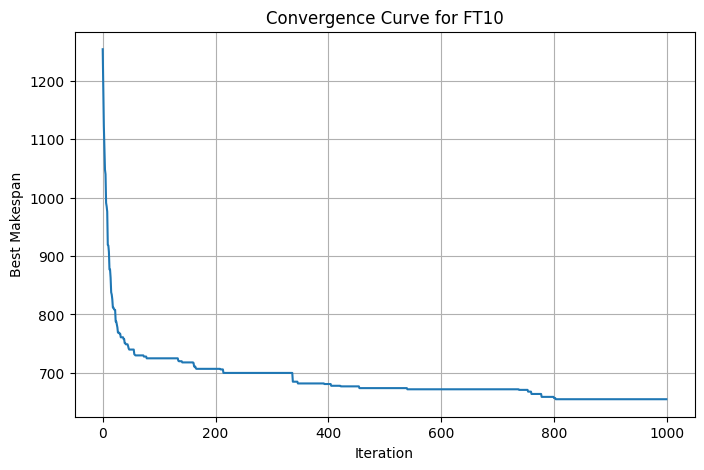

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(ft10_best_convergence)
plt.xlabel("Iteration")
plt.ylabel("Best Makespan")
plt.title("Convergence Curve for FT10")
plt.grid(True)
plt.show()

In [20]:
def plot_gantt(schedule):

    fig, ax = plt.subplots(figsize=(12, 6))

    colors = plt.cm.tab20.colors

    for operation in schedule:

        job_id, operation_id, machine_id, start, end = operation

        ax.barh(
            machine_id,
            end - start,
            left=start,
            color=colors[job_id % len(colors)],
            edgecolor='black'
        )

        ax.text(
            start + (end - start) / 2,
            machine_id,
            f'J{job_id}',
            ha='center',
            va='center',
            color='black',
            fontsize=8
        )

    ax.set_xlabel("Time")
    ax.set_ylabel("Machine")
    ax.set_title("Gantt Chart for FT10")

    plt.grid(True)

    plt.show()

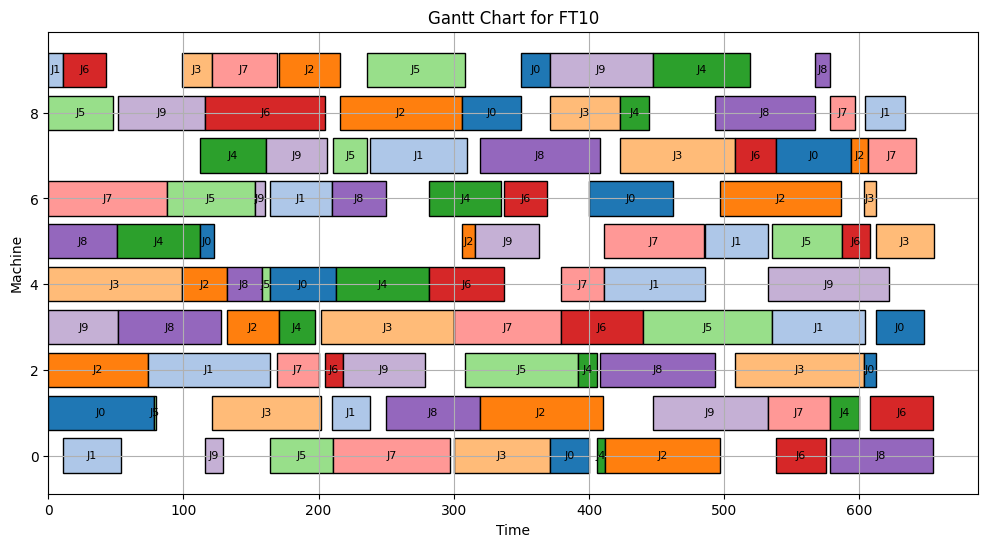

In [21]:
plot_gantt(best_schedule_ft10)

## FT20 Benchmark Instance Definition

In [22]:
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# FT20 / MT20 Benchmark Data
# Fisher and Thompson 20x5 Job-Shop instance
# Format: (machine_id, processing_time)
# -----------------------------

ft20_data = [
    [(0, 29), (1, 9),  (2, 49), (3, 62), (4, 44)],
    [(0, 43), (1, 75), (3, 69), (2, 46), (4, 72)],
    [(1, 91), (0, 39), (2, 90), (4, 12), (3, 45)],
    [(1, 81), (0, 71), (4, 9),  (2, 85), (3, 22)],
    [(2, 14), (1, 22), (0, 26), (3, 21), (4, 72)],
    [(2, 84), (1, 52), (4, 48), (0, 47), (3, 6)],
    [(1, 46), (0, 61), (2, 32), (3, 32), (4, 30)],
    [(2, 31), (1, 46), (0, 32), (3, 19), (4, 36)],
    [(0, 76), (3, 76), (2, 85), (1, 40), (4, 26)],
    [(1, 85), (2, 61), (0, 64), (3, 47), (4, 90)],
    [(1, 78), (3, 36), (0, 11), (4, 56), (2, 21)],
    [(2, 90), (0, 11), (1, 28), (3, 46), (4, 30)],
    [(0, 85), (2, 74), (1, 10), (3, 89), (4, 33)],
    [(2, 95), (0, 99), (1, 52), (3, 98), (4, 43)],
    [(0, 6),  (1, 61), (4, 69), (2, 49), (3, 53)],
    [(1, 2),  (0, 95), (3, 72), (4, 65), (2, 25)],
    [(0, 37), (2, 13), (1, 21), (3, 89), (4, 55)],
    [(0, 86), (1, 74), (4, 88), (2, 48), (3, 79)],
    [(1, 69), (2, 51), (0, 11), (3, 89), (4, 74)],
    [(0, 13), (1, 7),  (2, 76), (3, 52), (4, 45)]
]

ft20_machines = 5


# -----------------------------
# Initial Solution
# -----------------------------

def generate_initial_solution(jobs_data):
    solution = []

    for job_id, operations in enumerate(jobs_data):
        for _ in operations:
            solution.append(job_id)

    random.shuffle(solution)
    return solution


# -----------------------------
# Decode Solution
# -----------------------------

def decode_solution(solution, jobs_data, num_machines):
    job_operation_index = [0] * len(jobs_data)
    job_available_time = [0] * len(jobs_data)
    machine_available_time = [0] * num_machines
    schedule = []

    for job_id in solution:
        operation_index = job_operation_index[job_id]

        if operation_index >= len(jobs_data[job_id]):
            continue

        machine_id, processing_time = jobs_data[job_id][operation_index]

        start_time = max(job_available_time[job_id], machine_available_time[machine_id])
        completion_time = start_time + processing_time

        schedule.append({
            "job": job_id,
            "operation": operation_index,
            "machine": machine_id,
            "start": start_time,
            "completion": completion_time,
            "processing_time": processing_time
        })

        job_available_time[job_id] = completion_time
        machine_available_time[machine_id] = completion_time
        job_operation_index[job_id] += 1

    makespan = max(machine_available_time)
    return schedule, makespan


# -----------------------------
# Generate Neighbour
# -----------------------------

def generate_neighbor(solution):
    neighbor = solution.copy()

    i, j = random.sample(range(len(solution)), 2)
    neighbor[i], neighbor[j] = neighbor[j], neighbor[i]

    move = (i, j)
    return neighbor, move


# -----------------------------
# Tabu Search Algorithm
# -----------------------------

def tabu_search(jobs_data, num_machines, max_iterations=1000, tabu_tenure=7, neighborhood_size=50):
    current_solution = generate_initial_solution(jobs_data)
    current_schedule, current_makespan = decode_solution(current_solution, jobs_data, num_machines)

    best_solution = current_solution.copy()
    best_schedule = current_schedule
    best_makespan = current_makespan

    tabu_list = {}
    convergence = []

    for iteration in range(max_iterations):
        best_neighbor = None
        best_neighbor_schedule = None
        best_neighbor_makespan = float("inf")
        best_move = None

        for _ in range(neighborhood_size):
            neighbor, move = generate_neighbor(current_solution)
            neighbor_schedule, neighbor_makespan = decode_solution(neighbor, jobs_data, num_machines)

            reverse_move = (move[1], move[0])
            is_tabu = move in tabu_list or reverse_move in tabu_list

            if (not is_tabu) or (neighbor_makespan < best_makespan):
                if neighbor_makespan < best_neighbor_makespan:
                    best_neighbor = neighbor
                    best_neighbor_schedule = neighbor_schedule
                    best_neighbor_makespan = neighbor_makespan
                    best_move = move

        if best_neighbor is None:
            convergence.append(best_makespan)
            continue

        current_solution = best_neighbor
        current_schedule = best_neighbor_schedule
        current_makespan = best_neighbor_makespan

        tabu_list[best_move] = tabu_tenure

        expired_moves = []
        for move in list(tabu_list.keys()):
            tabu_list[move] -= 1
            if tabu_list[move] <= 0:
                expired_moves.append(move)

        for move in expired_moves:
            del tabu_list[move]

        if current_makespan < best_makespan:
            best_solution = current_solution.copy()
            best_schedule = current_schedule
            best_makespan = current_makespan

        convergence.append(best_makespan)

    return best_solution, best_schedule, best_makespan, convergence


# -----------------------------
# Run Experiments
# -----------------------------

def run_experiments(instance_data, num_machines, num_runs=10, max_iterations=1000, tabu_tenure=7, neighborhood_size=50):
    results = []
    times = []

    overall_best_solution = None
    overall_best_schedule = None
    overall_best_makespan = float("inf")
    overall_best_convergence = None

    for run in range(num_runs):
        start_time = time.time()

        best_solution, best_schedule, best_makespan, convergence = tabu_search(
            instance_data,
            num_machines,
            max_iterations=max_iterations,
            tabu_tenure=tabu_tenure,
            neighborhood_size=neighborhood_size
        )

        end_time = time.time()
        runtime = end_time - start_time

        results.append(best_makespan)
        times.append(runtime)

        if best_makespan < overall_best_makespan:
            overall_best_solution = best_solution
            overall_best_schedule = best_schedule
            overall_best_makespan = best_makespan
            overall_best_convergence = convergence

        print(f"Run {run + 1}: Makespan = {best_makespan}, Time = {runtime:.2f} seconds")

    summary = {
        "Best": min(results),
        "Worst": max(results),
        "Mean": np.mean(results),
        "Std Dev": np.std(results),
        "Avg Time": np.mean(times)
    }

    return summary, results, times, overall_best_solution, overall_best_schedule, overall_best_convergence


# -----------------------------
# FT20 Experiment
# -----------------------------

ft20_summary, ft20_results, ft20_times, ft20_best_solution, ft20_best_schedule, ft20_best_convergence = run_experiments(
    ft20_data,
    ft20_machines,
    num_runs=10,
    max_iterations=1000,
    tabu_tenure=7,
    neighborhood_size=50
)

print("\nFT20 Summary:")
print(ft20_summary)

Run 1: Makespan = 1296, Time = 3.30 seconds
Run 2: Makespan = 1184, Time = 4.65 seconds
Run 3: Makespan = 1243, Time = 3.28 seconds
Run 4: Makespan = 1204, Time = 3.27 seconds
Run 5: Makespan = 1270, Time = 3.51 seconds
Run 6: Makespan = 1261, Time = 4.47 seconds
Run 7: Makespan = 1228, Time = 3.28 seconds
Run 8: Makespan = 1193, Time = 3.28 seconds
Run 9: Makespan = 1289, Time = 4.67 seconds
Run 10: Makespan = 1207, Time = 3.28 seconds

FT20 Summary:
{'Best': 1184, 'Worst': 1296, 'Mean': np.float64(1237.5), 'Std Dev': np.float64(38.33862282346615), 'Avg Time': np.float64(3.698884105682373)}


## FT20 Experimental Results and Visualization

In [23]:
ft20_best_known = 1165
ft20_gap = ((ft20_summary["Best"] - ft20_best_known) / ft20_best_known) * 100

ft20_table = pd.DataFrame([{
    "Instance": "FT20",
    "Size": "20 x 5",
    "Best Known": ft20_best_known,
    "Best Found": ft20_summary["Best"],
    "Mean": round(ft20_summary["Mean"], 2),
    "Std Dev": round(ft20_summary["Std Dev"], 2),
    "Worst": ft20_summary["Worst"],
    "Avg. Time (s)": round(ft20_summary["Avg Time"], 2),
    "Gap (%)": round(ft20_gap, 2)
}])

ft20_table

,Instance,Size,Best Known,Best Found,Mean,Std Dev,Worst,Avg. Time (s),Gap (%)
0,FT20,20 x 5,1165,1184,1237.5,38.34,1296,3.7,1.63


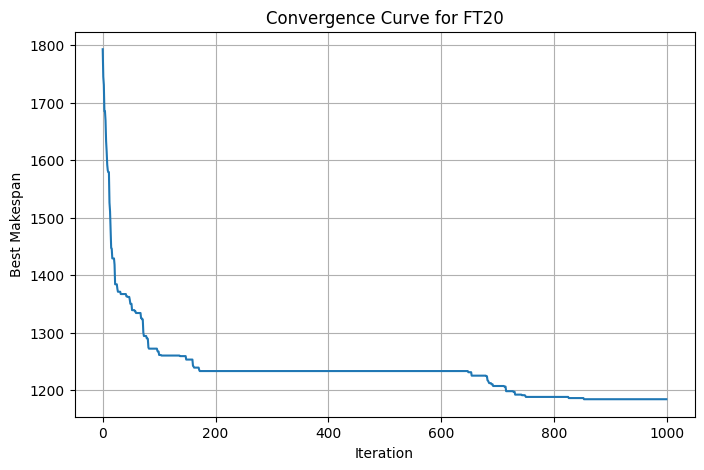

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(ft20_best_convergence)
plt.xlabel("Iteration")
plt.ylabel("Best Makespan")
plt.title("Convergence Curve for FT20")
plt.grid(True)
plt.show()

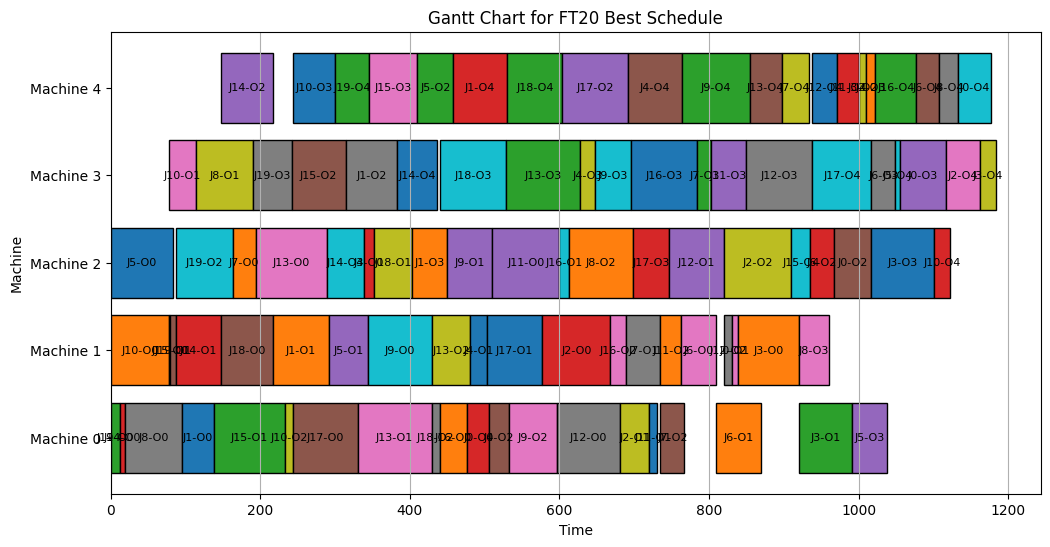

In [25]:
def plot_gantt(schedule, num_machines, title="Gantt Chart"):
    """
    Plots a Gantt chart for the given schedule.
    """
    plt.figure(figsize=(12, 6))

    for operation in schedule:
        machine = operation["machine"]
        start = operation["start"]
        duration = operation["processing_time"]
        job = operation["job"]

        plt.barh(machine, duration, left=start, edgecolor="black")
        plt.text(
            start + duration / 2,
            machine,
            f"J{job}-O{operation['operation']}",
            ha="center",
            va="center",
            fontsize=8
        )

    plt.xlabel("Time")
    plt.ylabel("Machine")
    plt.title(title)
    plt.yticks(range(num_machines), [f"Machine {i}" for i in range(num_machines)])
    plt.grid(axis="x")
    plt.show()


plot_gantt(
    ft20_best_schedule,
    ft20_machines,
    title="Gantt Chart for FT20 Best Schedule"
)

## LA30 Benchmark Instance Definition

In [ ]:
# LA30 - Lawrence 20x10 Job-Shop instance

la30_data = [
    [(6, 32), (3, 16), (1, 33), (8, 12), (7, 70), (4, 10), (9, 75), (0, 82), (5, 88), (2, 20)],
    [(8, 39), (4, 81), (3, 91), (5, 56), (9, 69), (1, 45), (6, 59), (0, 86), (2, 36), (7, 68)],
    [(3, 84), (2, 57), (7, 41), (5, 73), (4, 81), (0, 88), (8, 38), (9, 17), (6, 83), (1, 5)],
    [(4, 20), (5, 6),  (2, 15), (8, 19), (1, 30), (0, 94), (6, 45), (7, 17), (3, 18), (9, 88)],
    [(9, 24), (6, 49), (5, 16), (4, 11), (3, 60), (7, 5),  (8, 63), (1, 25), (2, 15), (0, 45)],
    [(1, 86), (8, 50), (2, 77), (6, 54), (9, 48), (0, 93), (3, 32), (7, 92), (5, 45), (4, 71)],
    [(5, 86), (6, 90), (3, 78), (9, 88), (2, 57), (0, 32), (7, 57), (8, 86), (4, 71), (1, 39)],
    [(2, 59), (3, 18), (9, 31), (4, 41), (7, 20), (5, 83), (8, 65), (0, 54), (6, 94), (1, 69)],
    [(3, 47), (4, 79), (6, 76), (0, 59), (1, 72), (2, 8),  (9, 30), (5, 73), (7, 57), (8, 84)],
    [(0, 59), (2, 89), (4, 10), (7, 45), (3, 8),  (5, 54), (6, 88), (8, 20), (9, 7),  (1, 62)],
    [(5, 63), (6, 9),  (4, 77), (3, 37), (2, 5),  (8, 13), (9, 79), (1, 24), (7, 10), (0, 82)],
    [(0, 74), (1, 32), (2, 61), (7, 53), (4, 92), (9, 20), (8, 10), (3, 5),  (6, 45), (5, 23)],
    [(2, 85), (9, 51), (0, 61), (5, 99), (4, 37), (6, 94), (1, 98), (8, 65), (3, 33), (7, 75)],
    [(0, 51), (3, 24), (5, 8),  (6, 30), (7, 12), (8, 23), (2, 7),  (4, 17), (9, 35), (1, 81)],
    [(1, 71), (5, 42), (8, 68), (2, 31), (6, 29), (3, 63), (4, 65), (9, 70), (7, 27), (0, 93)],
    [(1, 28), (5, 38), (4, 51), (7, 70), (2, 33), (8, 78), (9, 45), (3, 90), (6, 54), (0, 72)],
    [(0, 18), (2, 90), (4, 25), (6, 92), (8, 85), (5, 35), (7, 29), (1, 81), (9, 80), (3, 59)],
    [(5, 67), (2, 96), (1, 38), (4, 86), (0, 97), (3, 94), (7, 86), (6, 35), (9, 82), (8, 45)],
    [(2, 92), (8, 51), (4, 59), (6, 52), (5, 8),  (9, 70), (1, 75), (3, 54), (7, 60), (0, 33)],
    [(3, 98), (7, 80), (5, 78), (0, 82), (2, 7),  (9, 89), (1, 69), (4, 51), (8, 79), (6, 62)]
]

la30_machines = 10

print("LA30 jobs:", len(la30_data))
print("LA30 machines:", la30_machines)
print("Operations per job:", len(la30_data[0]))

LA30 jobs: 20
LA30 machines: 10
Operations per job: 10


In [ ]:
la30_summary, la30_results, la30_times, la30_best_solution, la30_best_schedule, la30_best_convergence = run_experiments(
    la30_data,
    la30_machines,
    num_runs=10,
    max_iterations=1000,
    tabu_tenure=7,
    neighborhood_size=50
)

print("\nLA30 Summary:")
print(la30_summary)

Run 1: Makespan = 1355, Time = 8.84 seconds
Run 2: Makespan = 1501, Time = 8.16 seconds
Run 3: Makespan = 1446, Time = 6.81 seconds
Run 4: Makespan = 1436, Time = 8.36 seconds
Run 5: Makespan = 1386, Time = 6.83 seconds
Run 6: Makespan = 1433, Time = 8.28 seconds
Run 7: Makespan = 1511, Time = 8.30 seconds
Run 8: Makespan = 1428, Time = 7.44 seconds
Run 9: Makespan = 1445, Time = 8.23 seconds
Run 10: Makespan = 1447, Time = 6.99 seconds

LA30 Summary:
{'Best': 1355, 'Worst': 1511, 'Mean': np.float64(1438.8), 'Std Dev': np.float64(43.8264760162165), 'Avg Time': np.float64(7.8235691547393795)}


## LA30 Experimental Results and Visualization

In [ ]:
la30_best_known = 1355
la30_gap = ((la30_summary["Best"] - la30_best_known) / la30_best_known) * 100

la30_table = pd.DataFrame([{
    "Instance": "LA30",
    "Size": "20 x 10",
    "Best Known": la30_best_known,
    "Best Found": la30_summary["Best"],
    "Mean": round(la30_summary["Mean"], 2),
    "Std Dev": round(la30_summary["Std Dev"], 2),
    "Worst": la30_summary["Worst"],
    "Avg. Time (s)": round(la30_summary["Avg Time"], 2),
    "Gap (%)": round(la30_gap, 2)
}])

la30_table

,Instance,Size,Best Known,Best Found,Mean,Std Dev,Worst,Avg. Time (s),Gap (%)
0,LA30,20 x 10,1355,1355,1438.8,43.83,1511,7.82,0.0


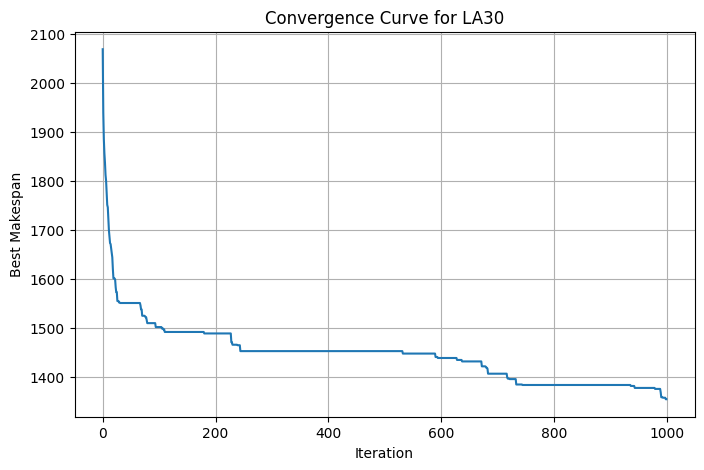

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(la30_best_convergence)
plt.xlabel("Iteration")
plt.ylabel("Best Makespan")
plt.title("Convergence Curve for LA30")
plt.grid(True)
plt.show()

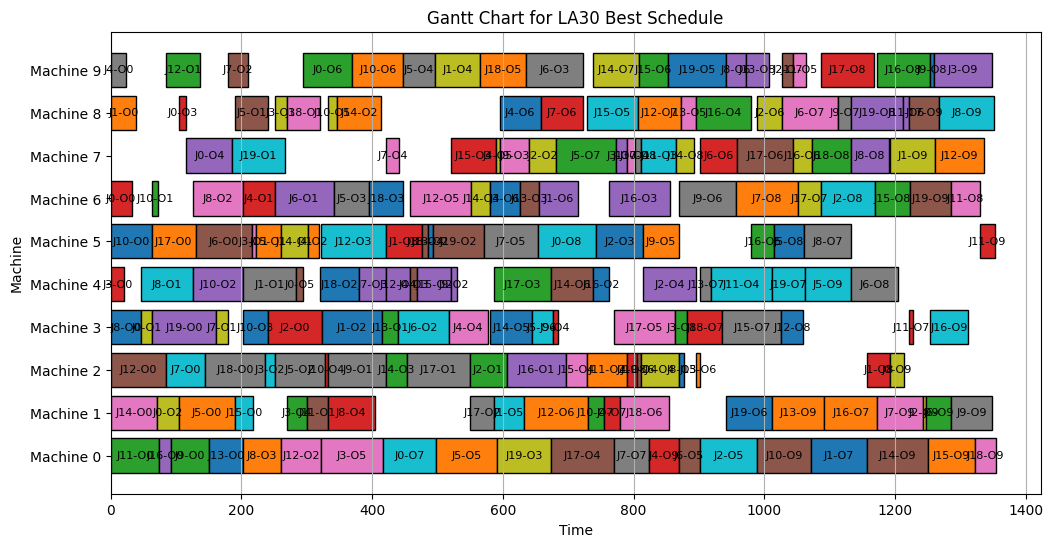

In [ ]:
plot_gantt(
    la30_best_schedule,
    la30_machines,
    title="Gantt Chart for LA30 Best Schedule"
)

## LA35 Benchmark Instance Definition

In [ ]:
# LA35 - Lawrence 30x10 Job-Shop instance

la35_data = [
    [(0, 66), (2, 84), (3, 26), (7, 29), (9, 94), (6, 98), (8, 7),  (5, 98), (1, 45), (4, 43)],
    [(3, 32), (0, 97), (6, 55), (2, 88), (8, 93), (9, 88), (1, 20), (4, 50), (7, 17), (5, 5)],
    [(4, 43), (3, 68), (8, 47), (9, 68), (1, 57), (6, 20), (5, 81), (2, 60), (7, 94), (0, 62)],
    [(1, 57), (5, 40), (0, 78), (6, 9),  (2, 49), (9, 17), (3, 32), (4, 30), (8, 87), (7, 77)],
    [(0, 52), (4, 30), (3, 48), (5, 48), (1, 26), (9, 17), (6, 93), (8, 97), (7, 49), (2, 89)],
    [(7, 95), (0, 33), (1, 5),  (6, 17), (5, 70), (3, 57), (4, 34), (2, 61), (8, 62), (9, 39)],
    [(7, 97), (5, 92), (1, 31), (8, 5),  (2, 79), (4, 5),  (3, 67), (0, 5),  (9, 78), (6, 60)],
    [(2, 79), (4, 6),  (7, 20), (8, 45), (6, 34), (3, 24), (9, 26), (5, 68), (1, 16), (0, 46)],
    [(7, 58), (9, 50), (2, 19), (8, 93), (6, 49), (3, 25), (5, 85), (4, 50), (0, 93), (1, 26)],
    [(9, 81), (6, 71), (5, 7),  (1, 39), (2, 16), (8, 42), (0, 71), (4, 84), (3, 56), (7, 99)],
    [(8, 9),  (0, 86), (9, 6),  (3, 71), (6, 97), (5, 85), (4, 16), (2, 42), (7, 81), (1, 81)],
    [(4, 72), (3, 24), (0, 30), (8, 56), (2, 43), (1, 61), (7, 82), (6, 40), (5, 59), (9, 43)],
    [(9, 43), (1, 13), (6, 70), (7, 93), (0, 95), (8, 12), (4, 15), (2, 78), (5, 97), (3, 14)],
    [(0, 14), (6, 26), (1, 71), (3, 46), (8, 80), (5, 31), (4, 37), (9, 27), (7, 92), (2, 67)],
    [(2, 12), (0, 43), (5, 96), (6, 7),  (3, 45), (7, 20), (1, 13), (9, 29), (4, 60), (8, 33)],
    [(1, 78), (5, 50), (6, 84), (0, 42), (8, 84), (4, 30), (9, 76), (2, 57), (7, 87), (3, 59)],
    [(4, 49), (7, 50), (1, 15), (8, 13), (0, 93), (6, 50), (9, 32), (5, 59), (3, 10), (2, 35)],
    [(1, 25), (0, 47), (7, 60), (8, 33), (4, 53), (5, 37), (9, 73), (2, 22), (3, 87), (6, 79)],
    [(0, 84), (6, 83), (1, 71), (5, 68), (9, 89), (8, 11), (3, 60), (4, 50), (2, 33), (7, 97)],
    [(1, 14), (0, 38), (6, 88), (5, 5),  (4, 77), (7, 92), (8, 24), (2, 73), (9, 52), (3, 71)],
    [(7, 62), (9, 19), (6, 38), (3, 15), (8, 64), (2, 64), (4, 8),  (1, 61), (0, 19), (5, 33)],
    [(2, 33), (5, 46), (4, 74), (0, 56), (6, 84), (9, 83), (8, 19), (7, 8),  (3, 32), (1, 97)],
    [(4, 50), (3, 71), (6, 50), (2, 97), (9, 8),  (0, 17), (7, 19), (8, 92), (5, 54), (1, 52)],
    [(8, 32), (1, 79), (3, 97), (5, 38), (9, 49), (4, 76), (6, 76), (0, 56), (2, 78), (7, 54)],
    [(5, 13), (3, 5),  (2, 25), (0, 86), (1, 95), (9, 28), (6, 78), (8, 24), (7, 10), (4, 39)],
    [(7, 48), (2, 59), (0, 20), (9, 7),  (5, 31), (6, 97), (1, 89), (4, 32), (3, 25), (8, 41)],
    [(5, 87), (0, 18), (9, 48), (2, 43), (1, 30), (6, 97), (7, 47), (8, 65), (3, 69), (4, 27)],
    [(6, 71), (5, 20), (8, 20), (1, 78), (3, 39), (0, 17), (7, 50), (2, 44), (9, 42), (4, 38)],
    [(0, 50), (9, 42), (3, 72), (5, 7),  (1, 77), (7, 58), (4, 78), (2, 89), (6, 70), (8, 36)],
    [(3, 32), (9, 95), (2, 13), (0, 73), (6, 97), (8, 24), (4, 49), (5, 57), (1, 68), (7, 94)]
]

la35_machines = 10

print("LA35 jobs:", len(la35_data))
print("LA35 machines:", la35_machines)
print("Operations per job:", len(la35_data[0]))

LA35 jobs: 30
LA35 machines: 10
Operations per job: 10


In [ ]:
la35_summary, la35_results, la35_times, la35_best_solution, la35_best_schedule, la35_best_convergence = run_experiments(
    la35_data,
    la35_machines,
    num_runs=10,
    max_iterations=1000,
    tabu_tenure=7,
    neighborhood_size=50
)

print("\nLA35 Summary:")
print(la35_summary)

Run 1: Makespan = 1908, Time = 11.70 seconds
Run 2: Makespan = 1888, Time = 11.52 seconds
Run 3: Makespan = 1912, Time = 11.56 seconds
Run 4: Makespan = 1891, Time = 12.10 seconds
Run 5: Makespan = 1928, Time = 11.61 seconds
Run 6: Makespan = 1971, Time = 11.71 seconds
Run 7: Makespan = 1896, Time = 11.55 seconds
Run 8: Makespan = 1888, Time = 10.61 seconds
Run 9: Makespan = 1955, Time = 11.26 seconds
Run 10: Makespan = 1888, Time = 11.60 seconds

LA35 Summary:
{'Best': 1888, 'Worst': 1971, 'Mean': np.float64(1912.5), 'Std Dev': np.float64(28.327548429046946), 'Avg Time': np.float64(11.521684432029724)}


## LA35 Experimental Results and Visualization

In [ ]:
la35_best_known = 1888
la35_gap = ((la35_summary["Best"] - la35_best_known) / la35_best_known) * 100

la35_table = pd.DataFrame([{
    "Instance": "LA35",
    "Size": "30 x 10",
    "Best Known": la35_best_known,
    "Best Found": la35_summary["Best"],
    "Mean": round(la35_summary["Mean"], 2),
    "Std Dev": round(la35_summary["Std Dev"], 2),
    "Worst": la35_summary["Worst"],
    "Avg. Time (s)": round(la35_summary["Avg Time"], 2),
    "Gap (%)": round(la35_gap, 2)
}])

la35_table

,Instance,Size,Best Known,Best Found,Mean,Std Dev,Worst,Avg. Time (s),Gap (%)
0,LA35,30 x 10,1888,1888,1912.5,28.33,1971,11.52,0.0


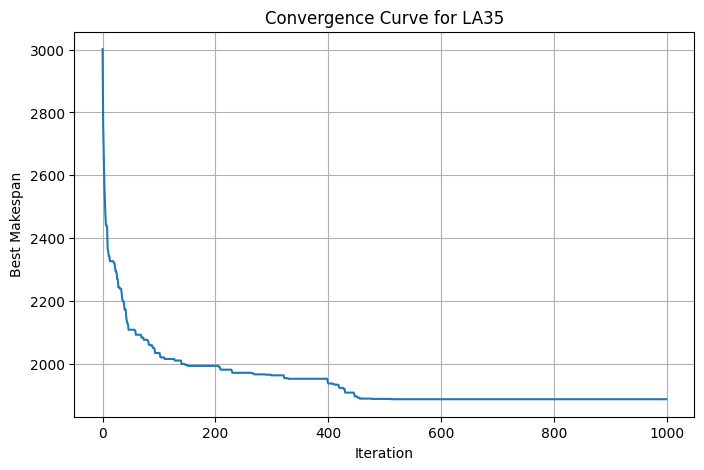

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(la35_best_convergence)
plt.xlabel("Iteration")
plt.ylabel("Best Makespan")
plt.title("Convergence Curve for LA35")
plt.grid(True)
plt.show()

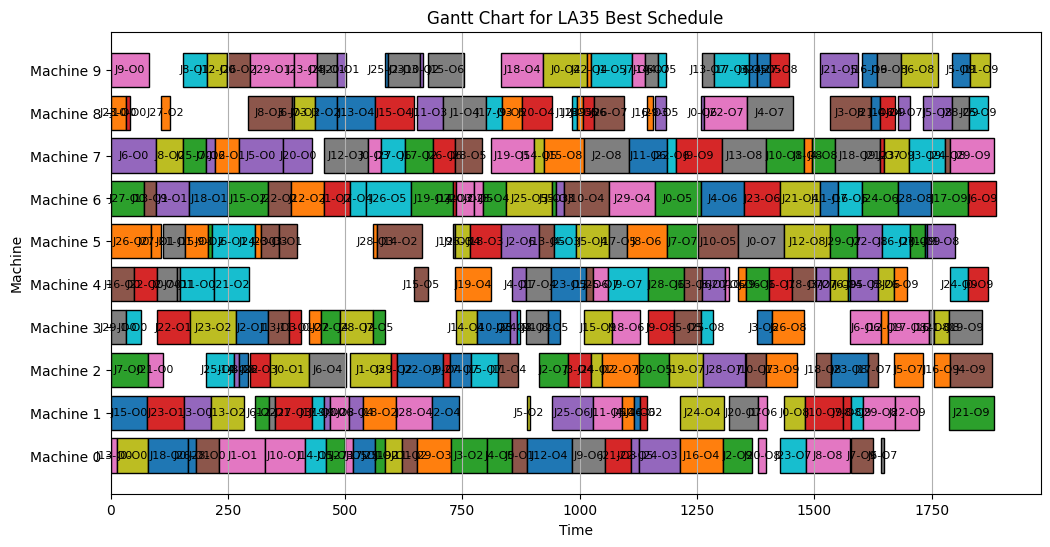

In [ ]:
plot_gantt(
    la35_best_schedule,
    la35_machines,
    title="Gantt Chart for LA35 Best Schedule"
)

## LA40 Benchmark Instance Definition

In [ ]:
# LA40 - Lawrence 15x15 Job-Shop instance

la40_data = [
    [(9, 65), (10, 28), (4, 74), (12, 33), (2, 51), (14, 75), (5, 73), (8, 32), (6, 13), (3, 81), (1, 35), (7, 59), (13, 38), (11, 55), (0, 27)],
    [(0, 64), (1, 53), (11, 83), (2, 33), (4, 6), (9, 52), (14, 72), (8, 7), (13, 90), (12, 21), (6, 23), (3, 10), (10, 39), (5, 49), (7, 72)],
    [(14, 73), (3, 82), (1, 23), (12, 62), (6, 88), (5, 21), (8, 65), (11, 70), (7, 53), (10, 81), (2, 93), (13, 77), (0, 61), (9, 28), (4, 78)],
    [(1, 12), (6, 51), (7, 33), (4, 15), (14, 72), (10, 98), (9, 94), (5, 12), (11, 42), (2, 24), (13, 15), (8, 28), (3, 6), (12, 99), (0, 41)],
    [(12, 97), (5, 7), (9, 96), (4, 15), (14, 73), (13, 43), (0, 32), (8, 22), (11, 42), (1, 94), (2, 23), (7, 86), (6, 78), (10, 24), (3, 31)],
    [(1, 72), (5, 88), (2, 93), (13, 13), (4, 44), (14, 66), (6, 63), (7, 14), (9, 67), (10, 17), (11, 85), (0, 35), (3, 68), (12, 5), (8, 49)],
    [(9, 15), (7, 82), (6, 21), (14, 53), (3, 72), (13, 49), (2, 99), (4, 26), (12, 56), (8, 45), (1, 68), (10, 51), (0, 8), (5, 27), (11, 96)],
    [(3, 54), (7, 24), (4, 14), (8, 38), (5, 36), (2, 52), (14, 55), (12, 37), (11, 48), (0, 93), (13, 60), (10, 70), (1, 23), (6, 23), (9, 83)],
    [(3, 12), (8, 69), (6, 26), (9, 23), (14, 28), (1, 82), (5, 33), (4, 45), (13, 64), (7, 15), (11, 9), (12, 73), (10, 59), (2, 37), (0, 62)],
    [(0, 87), (5, 12), (7, 80), (4, 50), (10, 48), (12, 90), (1, 72), (13, 24), (6, 14), (8, 71), (11, 44), (9, 46), (2, 15), (14, 61), (3, 92)],
    [(2, 54), (0, 22), (6, 61), (4, 46), (3, 73), (5, 16), (12, 6), (9, 94), (14, 93), (13, 67), (8, 54), (7, 75), (11, 32), (10, 40), (1, 97)],
    [(10, 92), (14, 36), (4, 22), (9, 9), (3, 47), (1, 77), (12, 79), (13, 36), (6, 30), (8, 98), (11, 79), (7, 7), (5, 55), (2, 6), (0, 30)],
    [(0, 49), (13, 83), (3, 73), (6, 82), (1, 82), (14, 92), (11, 73), (4, 31), (10, 35), (9, 54), (5, 7), (8, 37), (7, 72), (2, 52), (12, 76)],
    [(10, 98), (12, 34), (13, 52), (4, 26), (1, 28), (3, 39), (8, 80), (5, 29), (9, 70), (0, 43), (6, 48), (7, 58), (2, 45), (14, 94), (11, 96)],
    [(1, 70), (10, 17), (6, 90), (12, 67), (4, 14), (8, 23), (3, 21), (7, 18), (13, 43), (11, 84), (5, 26), (9, 36), (2, 93), (14, 84), (0, 42)]
]

la40_machines = 15

print("LA40 jobs:", len(la40_data))
print("LA40 machines:", la40_machines)
print("Operations per job:", len(la40_data[0]))

LA40 jobs: 15
LA40 machines: 15
Operations per job: 15


In [ ]:
la40_summary, la40_results, la40_times, la40_best_solution, la40_best_schedule, la40_best_convergence = run_experiments(
    la40_data,
    la40_machines,
    num_runs=10,
    max_iterations=1000,
    tabu_tenure=7,
    neighborhood_size=50
)

print("\nLA40 Summary:")
print(la40_summary)

Run 1: Makespan = 1491, Time = 9.22 seconds
Run 2: Makespan = 1353, Time = 7.63 seconds
Run 3: Makespan = 1299, Time = 9.12 seconds
Run 4: Makespan = 1412, Time = 9.13 seconds
Run 5: Makespan = 1297, Time = 7.55 seconds
Run 6: Makespan = 1324, Time = 9.03 seconds
Run 7: Makespan = 1404, Time = 9.13 seconds
Run 8: Makespan = 1331, Time = 7.62 seconds
Run 9: Makespan = 1349, Time = 9.69 seconds
Run 10: Makespan = 1376, Time = 9.10 seconds

LA40 Summary:
{'Best': 1297, 'Worst': 1491, 'Mean': np.float64(1363.6), 'Std Dev': np.float64(56.50168139091083), 'Avg Time': np.float64(8.723094964027405)}


## LA40 Experimental Results and Visualization

In [ ]:
la40_table = pd.DataFrame([{
    "Instance": "LA40",
    "Size": "15 x 15",
    "Best Known": "-",
    "Best Found": la40_summary["Best"],
    "Mean": round(la40_summary["Mean"], 2),
    "Std Dev": round(la40_summary["Std Dev"], 2),
    "Worst": la40_summary["Worst"],
    "Avg. Time (s)": round(la40_summary["Avg Time"], 2),
    "Gap (%)": "-"
}])

la40_table

,Instance,Size,Best Known,Best Found,Mean,Std Dev,Worst,Avg. Time (s),Gap (%)
0,LA40,15 x 15,-,1297,1363.6,56.5,1491,8.72,-


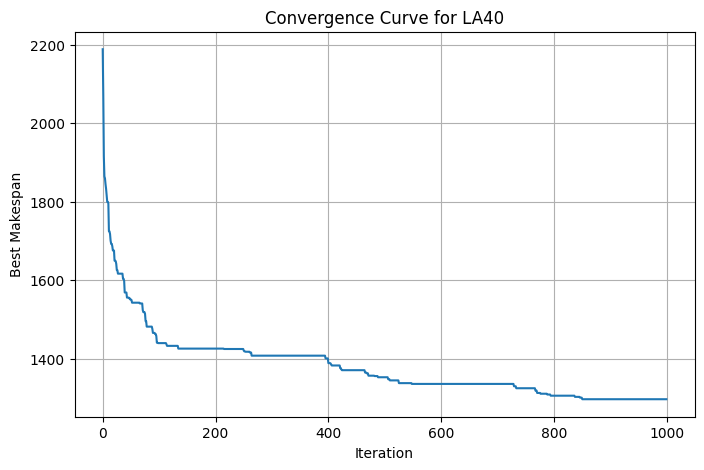

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(la40_best_convergence)
plt.xlabel("Iteration")
plt.ylabel("Best Makespan")
plt.title("Convergence Curve for LA40")
plt.grid(True)
plt.show()

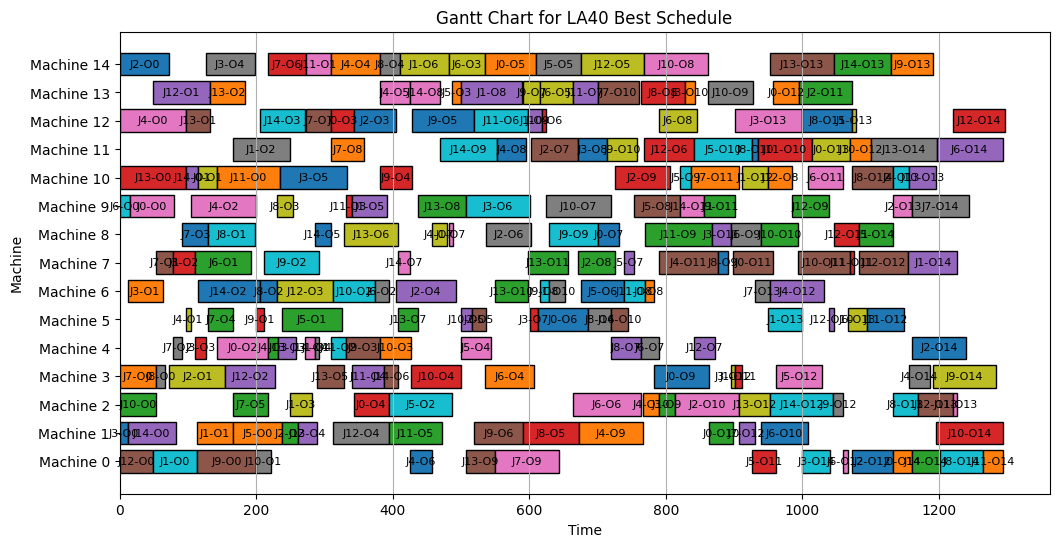

In [ ]:
plot_gantt(
    la40_best_schedule,
    la40_machines,
    title="Gantt Chart for LA40 Best Schedule"
)